In [ ]:
import helper_pfop as hpop

import pandas as pd
import numpy as np
import math

In [2]:
u = [0.08, 0.1, 0.12]
beta = 0.015
betas = [0.75 * beta, 0.5 * beta, 0.25 * beta]
phi = 0.75
r = 0.05
alpha = 0.05

X0     = 1.0
M      = 5.0
T = 8.0
# x = np.linspace(0.0, T, 1000)

x = hpop.time_grid_df(T, n=10000)

vt = np.array([[0.2, 0.0, 0.0],
                   [0.0, 0.25, 0.0],
                   [0.0, 0.0, 0.3]], dtype=float)

rhot = np.array([[1.0,  -0.6,  -0.8],
                     [-0.6,  1.0,  0.5],
                     [-0.8, 0.5,  1.0]], dtype=float)

leftside = np.linalg.inv(vt) @ np.linalg.inv(rhot) @ np.linalg.inv(vt)

In [3]:
b_all = [hpop.b_stock(u[i], betas[i], phi, x) for i in range(len(u))]
b_df = pd.concat(b_all, axis=1)
b_df.columns = [f"b_{i+1}" for i in range(len(b_all))]

B = hpop.B_t(b_df, r)

cov_target = vt @ rhot @ vt
theta = hpop.theta_norm_from_df(B, T = T, Cov = cov_target)
A = hpop.inthelog(T = 8)

epsilon_stern = hpop.solve_epsilon(theta, alpha = alpha, A = A)
optimal_strategies_for_min_risk = hpop.opt_strategy(epsilon_stern, theta, cov_target, B)

epsilon_stern_avar = hpop.solve_epsilon_avar_lel(theta, alpha = alpha, A=A * alpha)
optimal_strategies_for_min_risk_avar = hpop.opt_strategy(epsilon_stern_avar, theta, cov_target, B)

epsilon_stern_lel = hpop.solve_epsilon_avar_lel(theta, alpha = alpha, A=A * alpha, lel = True)
optimal_strategies_for_min_risk_lel = hpop.opt_strategy(epsilon_stern_lel, theta, cov_target, B)

In [4]:
# for the min risk for given expected wealth
chi = math.log(M / (X0 * np.exp(r * T)))
optimal_strategies_for_min_risk_given_M = hpop.opt_strategy(chi, theta, cov_target, B)

optimal_strategies_for_min_risk = hpop.prep_r_col(optimal_strategies_for_min_risk)
optimal_strategies_for_min_risk_avar = hpop.prep_r_col(optimal_strategies_for_min_risk_avar)
optimal_strategies_for_min_risk_lel = hpop.prep_r_col(optimal_strategies_for_min_risk_lel)
optimal_strategies_for_min_risk_given_M = hpop.prep_r_col(optimal_strategies_for_min_risk_given_M)

ak1, ak2, ak3, rfr = hpop.split_3dfs_into_4dfs_var_avar_lel(optimal_strategies_for_min_risk,
                                optimal_strategies_for_min_risk_avar, optimal_strategies_for_min_risk_lel)

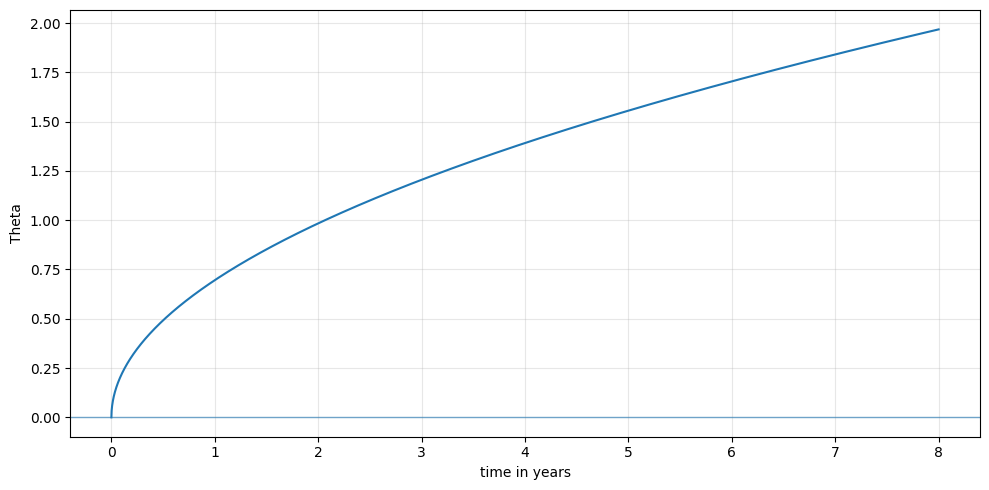

In [5]:
hpop.plot_theta(B, cov_target)

In [6]:
t = np.linspace(0.0, T, 10000)
X0 = 1
e_wealth = pd.DataFrame({
    "VaR":  [hpop.expected_wealth(epsilon_stern,  X0=X0, r=r, T=ti, B_df=B, covariance=cov_target) for ti in t],
    "AVaR": [hpop.expected_wealth(epsilon_stern_avar, X0=X0, r=r, T=ti, B_df=B, covariance=cov_target) for ti in t],
    "LEL":  [hpop.expected_wealth(epsilon_stern_lel,  X0=X0, r=r, T=ti, B_df=B, covariance=cov_target) for ti in t],
})

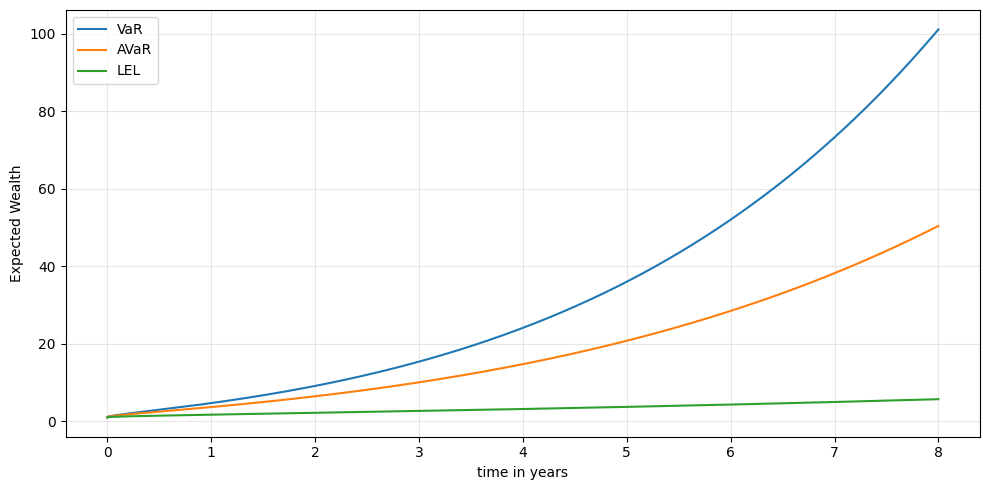

In [7]:
hpop.plot_helper(e_wealth, ylabel = "Expected Wealth")

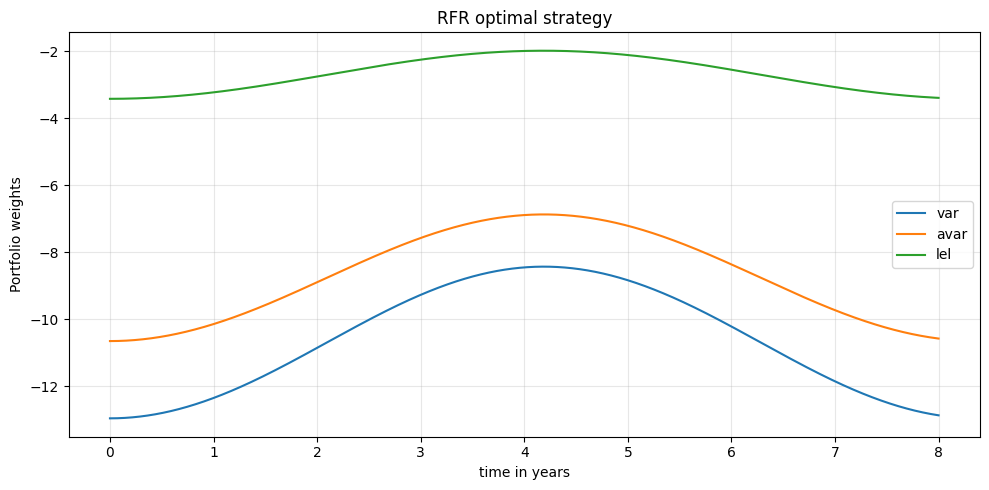

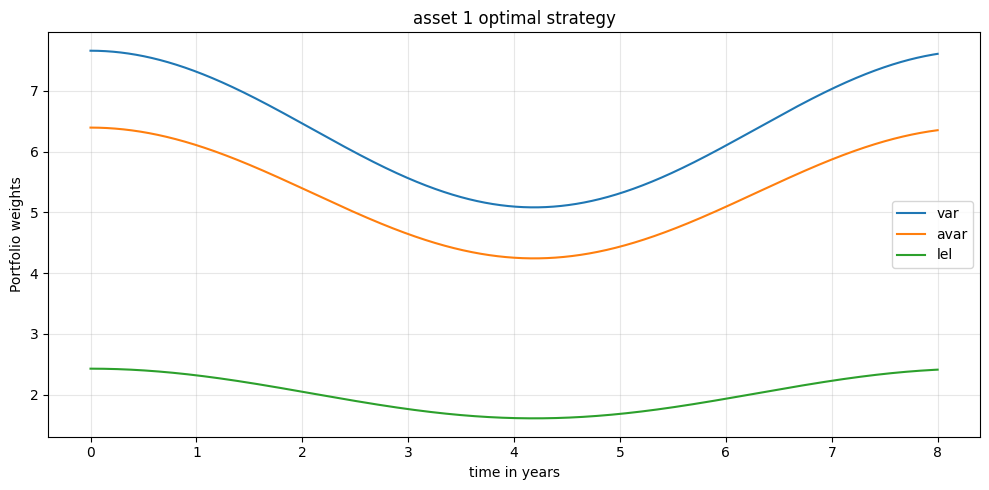

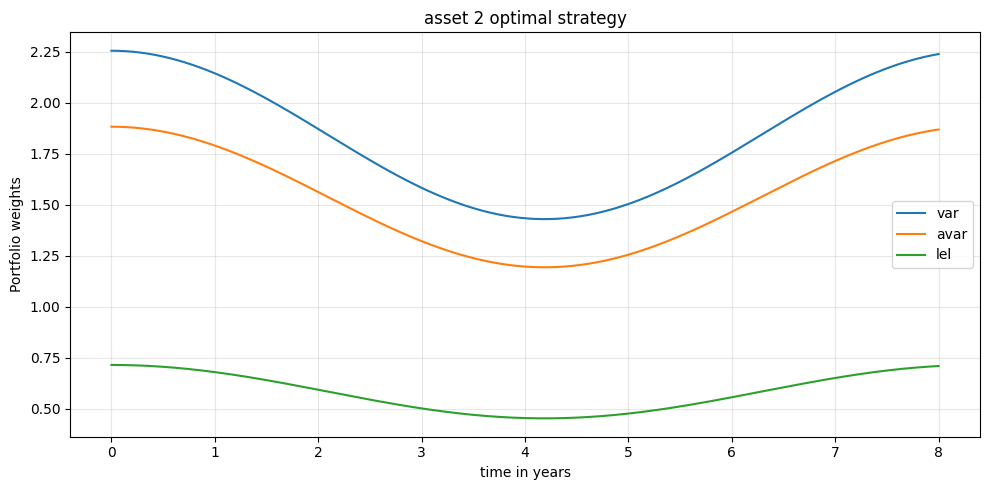

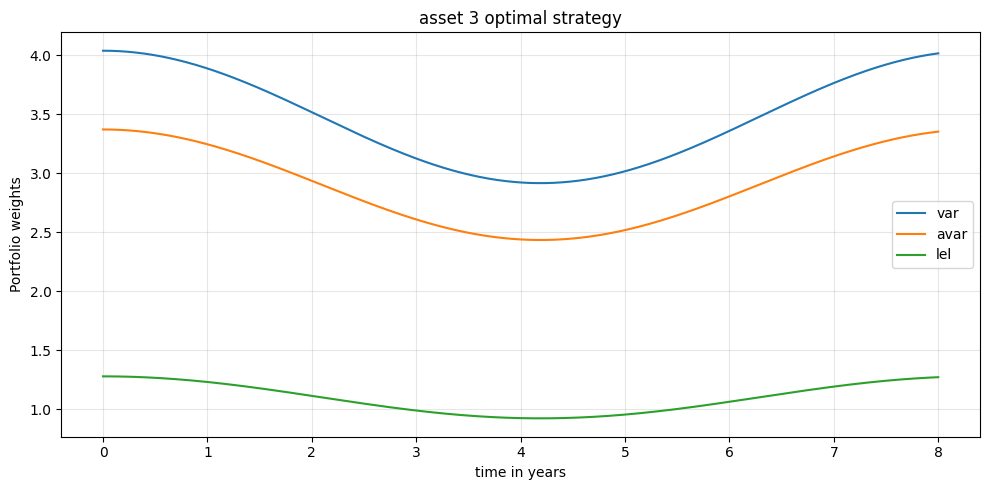

In [8]:
hpop.plot_helper(rfr, title= "RFR optimal strategy")
hpop.plot_helper(ak1, title= "asset 1 optimal strategy")
hpop.plot_helper(ak2, title= "asset 2 optimal strategy")
hpop.plot_helper(ak3, title= "asset 3 optimal strategy")

# Time Dependent Volatility

In [11]:
sigma_bar  = np.array([0.20, 0.25, 0.30])   # baseline vols
amplitude  = np.array([0.30, 0.20, 0.25])   # oscillation amplitudes 
omega      = np.pi / 4                       # one full cycle approximately 8 years

def vt_sinusoidal(t: float) -> np.ndarray:
    """Diagonal volatility matrix with sinusoidal time variation."""
    sigma_t = sigma_bar * (1.0 + amplitude * np.sin(omega * t))
    return np.diag(sigma_t)

# Regime based volatlity 
sigma_low  = np.array([0.15, 0.20, 0.22])
sigma_high = np.array([0.28, 0.35, 0.40])

def vt_regime(t: float) -> np.ndarray:
    """Diagonal volatility matrix that switches regime at T/2."""
    sigma_t = sigma_low if t < T / 2 else sigma_high
    return np.diag(sigma_t)

vt_func = vt_sinusoidal     # swap to vt_regime at any time
# vt_func = vt_regime   

In [12]:
t_lin, theta_td = hpop.theta_norm_td(B, T=T, vt_func=vt_func, rhot=rhot)
A_td     = hpop.inthelog(T=T)    

eps_var_td  = hpop.solve_epsilon(theta_td[-1], alpha=alpha, A=A_td)
eps_avar_td = hpop.solve_epsilon_avar_lel(theta_td[-1], alpha=alpha, A=A_td * alpha)
eps_lel_td  = hpop.solve_epsilon_avar_lel(theta_td[-1], alpha=alpha, A=A_td * alpha, lel=True)
chi_td      = math.log(M / (X0 * np.exp(r * T)))

strat_var_td  = hpop.opt_strategy_td(eps_var_td,  theta_td[-1], vt_func, rhot, B, T)
strat_avar_td = hpop.opt_strategy_td(eps_avar_td, theta_td[-1], vt_func, rhot, B, T)
strat_lel_td  = hpop.opt_strategy_td(eps_lel_td,  theta_td[-1], vt_func, rhot, B, T)
strat_M_td    = hpop.opt_strategy_td(chi_td,      theta_td[-1], vt_func, rhot, B, T)

strat_var_td  = hpop.prep_r_col(strat_var_td)
strat_avar_td = hpop.prep_r_col(strat_avar_td)
strat_lel_td  = hpop.prep_r_col(strat_lel_td)
strat_M_td    = hpop.prep_r_col(strat_M_td)

ak1_td, ak2_td, ak3_td, rfr_td = hpop.split_3dfs_into_4dfs_var_avar_lel(
    strat_var_td, strat_avar_td, strat_lel_td
)

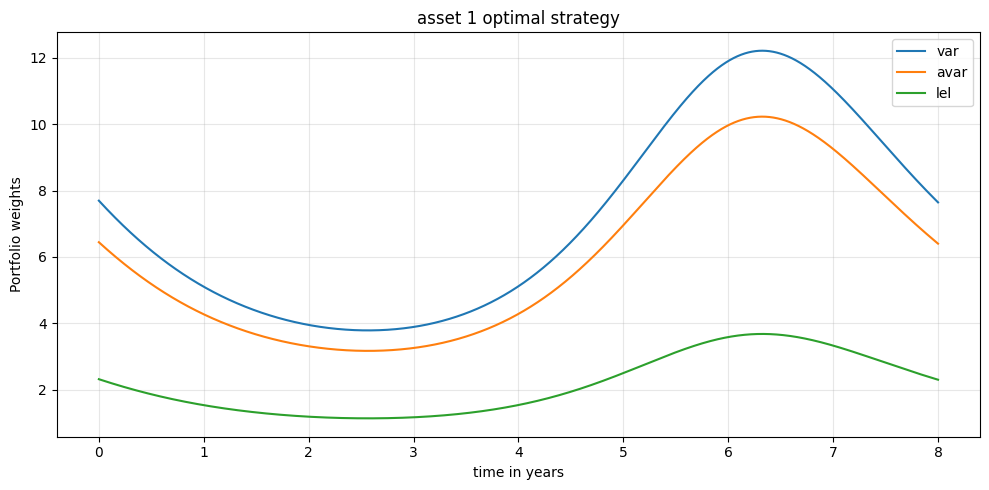

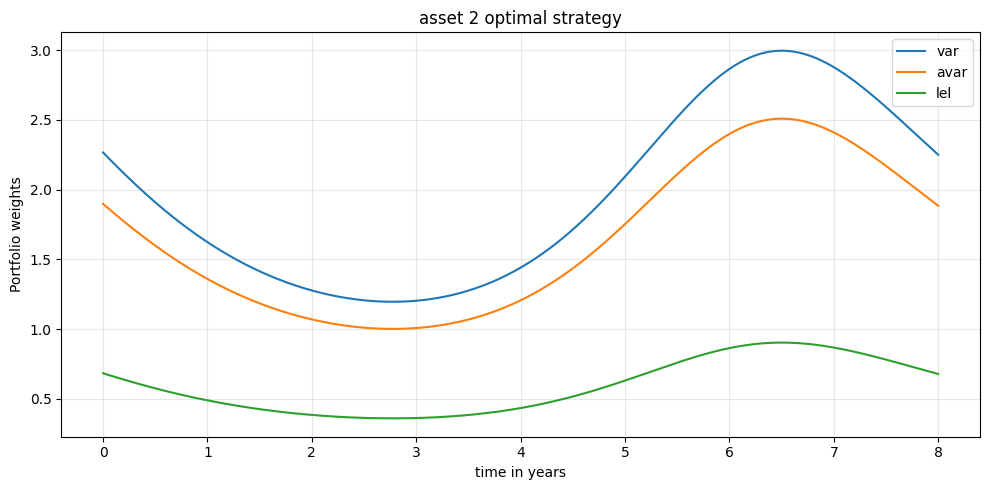

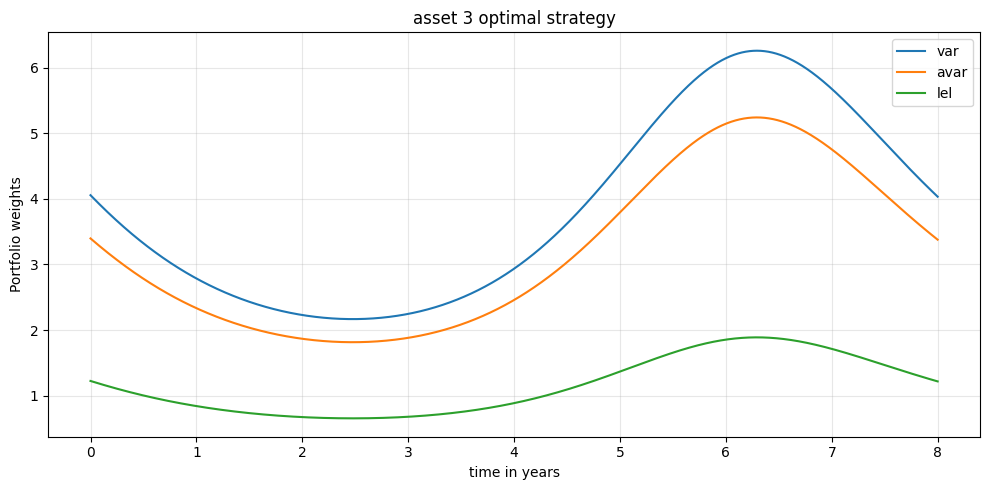

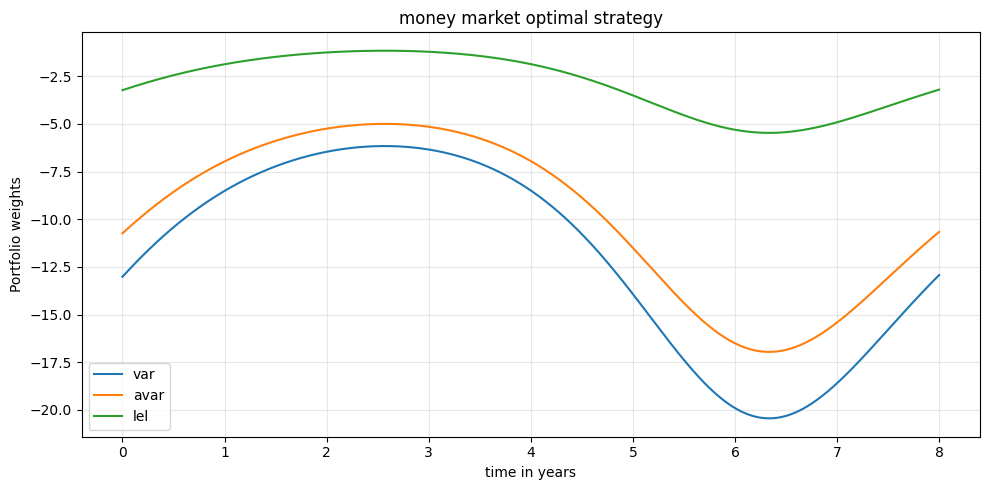

In [ ]:
hpop.plot_helper(ak1_td, title= "asset 1 optimal strategy")
hpop.plot_helper(ak2_td, title= "asset 2 optimal strategy")
hpop.plot_helper(ak3_td, title= "asset 3 optimal strategy")
hpop.plot_helper(rfr_td, title= "RFR optimal strategy")

In [7]:
e_wealth_td = pd.DataFrame({
    "VaR":  hpop.expected_wealth_td(eps_var_td,  X0=X0, r=r, B_df=B, T=T, vt_func=vt_func, rhot=rhot),
    "AVaR": hpop.expected_wealth_td(eps_avar_td,  X0=X0, r=r, B_df=B, T=T, vt_func=vt_func, rhot=rhot),
    "LEL":  hpop.expected_wealth_td(eps_lel_td,  X0=X0, r=r, B_df=B, T=T, vt_func=vt_func, rhot=rhot),
})

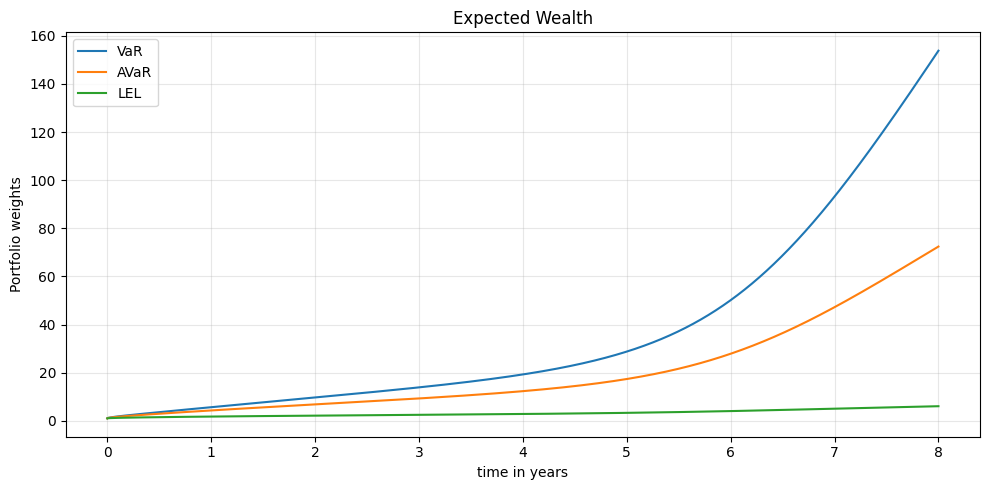

In [8]:
hpop.plot_helper(e_wealth_td, title= "Expected Wealth")